# Aviation Stripes — Dataset Construction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths — notebook lives in notebooks/, data in data/clean/
DATA_DIR = Path('../data/clean')
OUT_DIR  = Path('../data/clean')

print('Libraries loaded ✓')
print(f'Data dir: {DATA_DIR.resolve()}')

Libraries loaded ✓
Data dir: C:\Users\siria\OneDrive - Luiss\Desktop\Dataviz\Data-Visualization-\data\clean


## 1. Load cleaned datasets

In [2]:
airport = pd.read_csv(DATA_DIR / 'airport_clean.csv')
print(f'airport_clean:  {airport.shape[0]:,} rows × {airport.shape[1]} cols')
print(f'  Years: {sorted(airport["YEAR"].unique())}')
print(f'  Columns: {list(airport.columns)}')
airport.head(3)

airport_clean:  822,580 rows × 10 cols
  Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
  Columns: ['YEAR', 'MONTH_NUM', 'FLT_DATE', 'APT_ICAO', 'APT_NAME', 'STATE_NAME', 'FLT_DEP_1', 'FLT_ARR_1', 'FLT_TOT_1', 'DOW']


,YEAR,MONTH_NUM,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,DOW
0,2019,1,2019-01-01,LATI,Tirana,Albania,29,26,55,1
1,2019,1,2019-01-01,UDYZ,Yerevan,Armenia,29,33,62,1
2,2019,1,2019-01-01,LOWG,Graz,Austria,5,7,12,1


In [3]:
emissions = pd.read_csv(DATA_DIR / 'emission_network_clean.csv')
print(f'emission_network_clean: {emissions.shape[0]:,} rows × {emissions.shape[1]} cols')
print(f'  LEVEL:        {emissions["LEVEL"].unique()}')
print(f'  AREA (top 5): {list(emissions["AREA"].unique())[:5]}')
print(f'  FLIGHT_PHASE: {list(emissions["FLIGHT_PHASE"].unique())}')
print(f'  CO2 column:   CO2_KG')
emissions.head(3)

emission_network_clean: 55,621 rows × 12 cols
  LEVEL:        <ArrowStringArray>
['NETWORK']
Length: 1, dtype: str
  AREA (top 5): ['ECAC', 'EUROCONTROL', 'EU27+EFTA', 'EEA', 'RP3']
  FLIGHT_PHASE: ['cruise', 'descent', 'climb', 'taxi-in', 'taxi-out']
  CO2 column:   CO2_KG


,LEVEL,AREA,YEAR,MONTH,MARKET_SEGMENT,FLIGHT_TYPE,FLIGHT_PHASE,NB_FLIGHTS,NOX_KG,SOX_KG,CO2_KG,DATE
0,NETWORK,ECAC,2019,1,business,D,cruise,3247,91683.56,7080.21,26607300.0,2019-01-01
1,NETWORK,ECAC,2019,1,business,A,cruise,3428,69539.62,6150.15,23112000.0,2019-01-01
2,NETWORK,ECAC,2019,1,business,O,cruise,444,8766.93,717.68,2695700.0,2019-01-01


In [4]:
carbon = pd.read_csv(DATA_DIR / 'carbon_price_monthly_cleaned.csv')
print(f'carbon_price: {carbon.shape[0]} rows × {carbon.shape[1]} cols')
print(f'  EUA price range: {carbon["EUA_PRICE_EUR"].min():.2f} — {carbon["EUA_PRICE_EUR"].max():.2f} €/tCO₂')
carbon.head(3)

carbon_price: 72 rows × 4 cols
  EUA price range: 20.47 — 92.61 €/tCO₂


,DATE,YEAR,MONTH,EUA_PRICE_EUR
0,2019-01-01,2019,1,25.09
1,2019-02-01,2019,2,22.65
2,2019-03-01,2019,3,23.46


## 2. Monthly traffic

In [5]:
monthly_traffic = (
    airport
    .groupby(['YEAR', 'MONTH_NUM'])['FLT_TOT_1']
    .sum()
    .reset_index()
    .rename(columns={'MONTH_NUM': 'MONTH', 'FLT_TOT_1': 'TOTAL_FLIGHTS'})
)

# 2019 monthly baseline
baseline_2019 = (
    monthly_traffic[monthly_traffic['YEAR'] == 2019]
    .set_index('MONTH')['TOTAL_FLIGHTS']
)

monthly_traffic['BASELINE_2019'] = monthly_traffic['MONTH'].map(baseline_2019)
monthly_traffic['RECOVERY_PCT']  = (
    monthly_traffic['TOTAL_FLIGHTS'] / monthly_traffic['BASELINE_2019'] * 100
).round(1)

print(f'Monthly traffic: {len(monthly_traffic)} rows')
print(f'Recovery range:  {monthly_traffic["RECOVERY_PCT"].min():.1f}% — {monthly_traffic["RECOVERY_PCT"].max():.1f}%')
monthly_traffic.sort_values(['YEAR','MONTH']).head(6)

Monthly traffic: 87 rows
Recovery range:  10.0% — 103.3%


,YEAR,MONTH,TOTAL_FLIGHTS,BASELINE_2019,RECOVERY_PCT
0,2019,1,1225124,1225124,100.0
1,2019,2,1151456,1151456,100.0
2,2019,3,1317196,1317196,100.0
3,2019,4,1416839,1416839,100.0
4,2019,5,1539048,1539048,100.0
5,2019,6,1597854,1597854,100.0


## 3. Monthly emissions

In [7]:
# Filter ECAC network
em_ecac = emissions[
    (emissions['LEVEL'] == 'NETWORK') &
    (emissions['AREA']  == 'ECAC')
].copy()

print(f'ECAC network rows: {len(em_ecac):,}')
print(f'Years: {sorted(em_ecac["YEAR"].unique())}')

# Aggregate across all phases, segments, flight types
monthly_em = (
    em_ecac
    .groupby(['YEAR', 'MONTH'])
    .agg(
        CO2_KG    = ('CO2_KG',     'sum'),
        NB_FLIGHTS= ('NB_FLIGHTS', 'sum')
    )
    .reset_index()
)

# Convert units
monthly_em['CO2_TONS']       = monthly_em['CO2_KG'] / 1_000          # kg → tonnes
monthly_em['TOTAL_CO2_MT']   = (monthly_em['CO2_TONS'] / 1_000_000).round(2)  # tonnes → Mt
monthly_em['CO2_PER_FLIGHT'] = (monthly_em['CO2_TONS'] / monthly_em['NB_FLIGHTS']).round(3)

print(f'\nMonthly emissions: {len(monthly_em)} rows')
print(f'CO₂/flight range:  {monthly_em["CO2_PER_FLIGHT"].min():.3f} — {monthly_em["CO2_PER_FLIGHT"].max():.3f} t')
print(f'Total CO₂ range:   {monthly_em["TOTAL_CO2_MT"].min():.1f} — {monthly_em["TOTAL_CO2_MT"].max():.1f} Mt')
monthly_em.head(6)

ECAC network rows: 7,872
Years: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Monthly emissions: 72 rows
CO₂/flight range:  2.852 — 4.252 t
Total CO₂ range:   2.0 — 19.5 Mt


,YEAR,MONTH,CO2_KG,NB_FLIGHTS,CO2_TONS,TOTAL_CO2_MT,CO2_PER_FLIGHT
0,2019,1,1.238364e+10,3623257,12383643.5,12.38,3.418
1,2019,2,1.137695e+10,3395548,11376954.8,11.38,3.351
2,2019,3,1.313670e+10,3887841,13136697.0,13.14,3.379
3,2019,4,1.402469e+10,4197481,14024691.3,14.02,3.341
4,2019,5,1.502912e+10,4551558,15029121.4,15.03,3.302
5,2019,6,1.613862e+10,4781700,16138621.1,16.14,3.375


## 4. Merge traffic + emissions + carbon price

In [8]:
# Keep only 2019-2024 (emission data available)
traffic_subset = monthly_traffic[monthly_traffic['YEAR'] <= 2024].copy()

# Merge traffic + emissions
combined = traffic_subset.merge(
    monthly_em[['YEAR', 'MONTH', 'CO2_PER_FLIGHT', 'TOTAL_CO2_MT']],
    on=['YEAR', 'MONTH'],
    how='left'
)

# Merge carbon price
combined = combined.merge(
    carbon[['YEAR', 'MONTH', 'EUA_PRICE_EUR']],
    on=['YEAR', 'MONTH'],
    how='left'
)

combined = combined.sort_values(['YEAR', 'MONTH']).reset_index(drop=True)

print(f'Combined rows: {len(combined)} (expected: 72 = 6 years × 12 months)')
print(f'Missing CO₂:   {combined["CO2_PER_FLIGHT"].isna().sum()}')
print(f'Missing EUA:   {combined["EUA_PRICE_EUR"].isna().sum()}')
combined.head(6)

Combined rows: 72 (expected: 72 = 6 years × 12 months)
Missing CO₂:   0
Missing EUA:   0


,YEAR,MONTH,TOTAL_FLIGHTS,BASELINE_2019,RECOVERY_PCT,CO2_PER_FLIGHT,TOTAL_CO2_MT,EUA_PRICE_EUR
0,2019,1,1225124,1225124,100.0,3.418,12.38,25.09
1,2019,2,1151456,1151456,100.0,3.351,11.38,22.65
2,2019,3,1317196,1317196,100.0,3.379,13.14,23.46
3,2019,4,1416839,1416839,100.0,3.341,14.02,27.00
4,2019,5,1539048,1539048,100.0,3.302,15.03,26.61
5,2019,6,1597854,1597854,100.0,3.375,16.14,26.37


## 5. Add Tableau columns

- `STRIPE_INDEX` — sequential 1–72, X axis in Tableau  
- `DATE_LABEL` — human-readable tooltip label  
- `CONSTANT_100` — constant for the Stripes view (all bars same height)  
- `DIFF_*` — deviation from dataset mean (Warming Stripes / prof's method)

In [9]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

combined['STRIPE_INDEX']  = range(1, len(combined) + 1)
combined['MONTH_NAME']    = combined['MONTH'].apply(lambda m: MONTH_NAMES[m-1])
combined['DATE_LABEL']    = combined['MONTH_NAME'] + ' ' + combined['YEAR'].astype(str)
combined['CONSTANT_100']  = 100

# Difference from mean (prof's Warming Stripes technique)
combined['DIFF_RECOVERY'] = (combined['RECOVERY_PCT']  - combined['RECOVERY_PCT'].mean()).round(4)
combined['DIFF_CO2']      = (combined['CO2_PER_FLIGHT']- combined['CO2_PER_FLIGHT'].mean()).round(4)
combined['DIFF_TOTAL']    = (combined['TOTAL_CO2_MT']  - combined['TOTAL_CO2_MT'].mean()).round(4)

print('=== Dataset statistics ===')
print(f'Mean Recovery:     {combined["RECOVERY_PCT"].mean():.2f}%')
print(f'Mean CO₂/flight:   {combined["CO2_PER_FLIGHT"].mean():.3f} t')
print(f'Mean Total CO₂:    {combined["TOTAL_CO2_MT"].mean():.2f} Mt')
print(f'Mean EUA price:    {combined["EUA_PRICE_EUR"].mean():.2f} €/tCO₂')
combined[['DATE_LABEL','RECOVERY_PCT','CO2_PER_FLIGHT',
          'TOTAL_CO2_MT','EUA_PRICE_EUR','STRIPE_INDEX']].head(6)

=== Dataset statistics ===
Mean Recovery:     78.17%
Mean CO₂/flight:   3.513 t
Mean Total CO₂:    12.25 Mt
Mean EUA price:    56.22 €/tCO₂


,DATE_LABEL,RECOVERY_PCT,CO2_PER_FLIGHT,TOTAL_CO2_MT,EUA_PRICE_EUR,STRIPE_INDEX
0,Jan 2019,100.0,3.418,12.38,25.09,1
1,Feb 2019,100.0,3.351,11.38,22.65,2
2,Mar 2019,100.0,3.379,13.14,23.46,3
3,Apr 2019,100.0,3.341,14.02,27.00,4
4,May 2019,100.0,3.302,15.03,26.61,5
5,Jun 2019,100.0,3.375,16.14,26.37,6


## 6. Preview — Aviation Stripes in Python

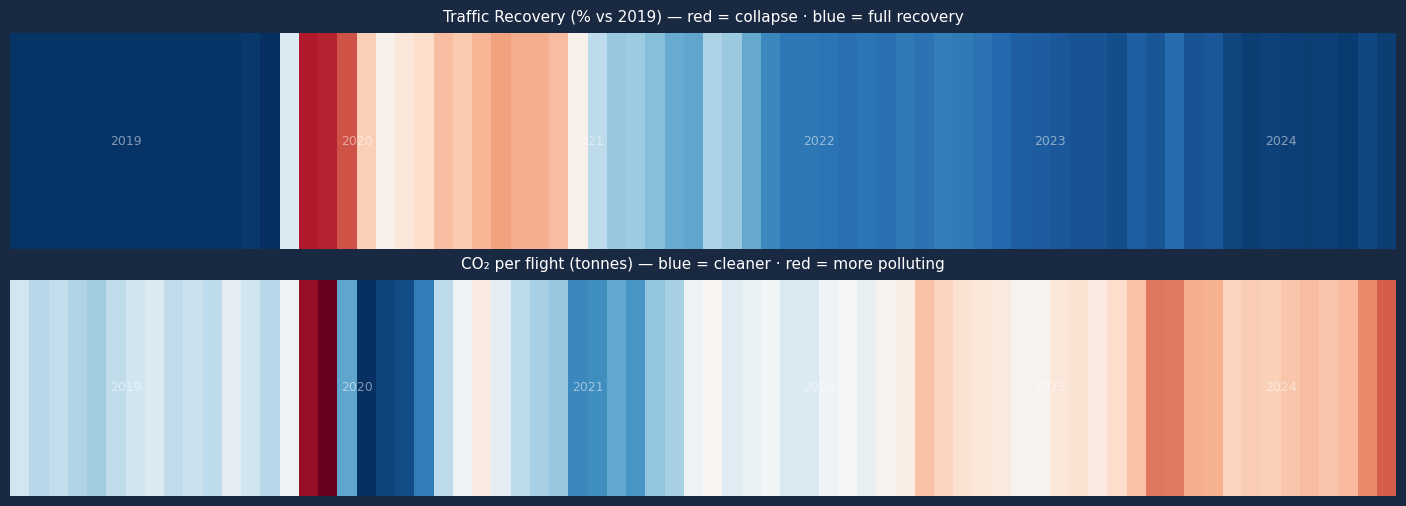

Preview saved → figures/aviation_stripes_preview.png


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5))
fig.patch.set_facecolor('#1a2942')

# Panel 1: Traffic Recovery
ax = axes[0]
ax.set_facecolor('#1a2942')
cmap_r = plt.cm.RdBu
norm_r  = mcolors.Normalize(vmin=0, vmax=101)
for _, row in combined.iterrows():
    ax.bar(row['STRIPE_INDEX'], 1,
           color=cmap_r(norm_r(row['RECOVERY_PCT'])),
           width=1, align='center')
for yr in range(2019, 2025):
    idx = combined[combined['YEAR'] == yr]['STRIPE_INDEX'].mean()
    ax.text(idx, 0.5, str(yr), ha='center', va='center',
            color='white', fontsize=9, alpha=0.5)
ax.set_xlim(0.5, 72.5)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Traffic Recovery (% vs 2019) — red = collapse · blue = full recovery',
             color='white', fontsize=11, pad=8)

# Panel 2: CO2 per flight
ax2 = axes[1]
ax2.set_facecolor('#1a2942')
cmap_c = plt.cm.RdBu_r
norm_c  = mcolors.Normalize(
    vmin=combined['CO2_PER_FLIGHT'].min(),
    vmax=combined['CO2_PER_FLIGHT'].max()
)
for _, row in combined.iterrows():
    ax2.bar(row['STRIPE_INDEX'], 1,
            color=cmap_c(norm_c(row['CO2_PER_FLIGHT'])),
            width=1, align='center')
for yr in range(2019, 2025):
    idx = combined[combined['YEAR'] == yr]['STRIPE_INDEX'].mean()
    ax2.text(idx, 0.5, str(yr), ha='center', va='center',
             color='white', fontsize=9, alpha=0.5)
ax2.set_xlim(0.5, 72.5)
ax2.set_ylim(0, 1)
ax2.axis('off')
ax2.set_title('CO₂ per flight (tonnes) — blue = cleaner · red = more polluting',
              color='white', fontsize=11, pad=8)

plt.tight_layout(pad=0.5)
fig.savefig('../figures/aviation_stripes_preview.png',
            dpi=150, bbox_inches='tight', facecolor='#1a2942')
plt.show()
print('Preview saved → figures/aviation_stripes_preview.png')

## 7. Export

**IT version** — semicolon separator + comma decimal → for Tableau Desktop with Italian locale  
**EN version** — standard CSV → for Python, GitHub, other tools

In [13]:
# Final column selection and renaming
output_cols = {
    'YEAR':          'Year',
    'MONTH':         'Month_Num',
    'MONTH_NAME':    'Month_Name',
    'STRIPE_INDEX':  'Stripe_Index',
    'DATE_LABEL':    'Date_Label',
    'RECOVERY_PCT':  'Recovery_Pct',
    'CO2_PER_FLIGHT':'CO2_per_Flight',
    'TOTAL_CO2_MT':  'Total_CO2_Mt',
    'EUA_PRICE_EUR': 'EUA_Price_EUR',
    'CONSTANT_100':  'Constant_100',
    'DIFF_RECOVERY': 'Diff_Recovery',
    'DIFF_CO2':      'Diff_CO2',
    'DIFF_TOTAL':    'Diff_Total',
}

df_out = combined[list(output_cols.keys())].rename(columns=output_cols)

# --- Export 1: Italian locale (semicolon + comma decimal) ---
path_it = OUT_DIR / 'aviation_stripes_IT.csv'
with open(path_it, 'w', encoding='utf-8-sig') as f:
    f.write(';'.join(df_out.columns) + '\n')
    for _, row in df_out.iterrows():
        vals = []
        for col in df_out.columns:
            v = row[col]
            if isinstance(v, float):
                vals.append(str(round(v, 4)).replace('.', ','))
            else:
                vals.append(str(v))
        f.write(';'.join(vals) + '\n')
print(f' {path_it} — {len(df_out)} rows (Tableau IT locale)')

# --- Export 2: Standard English CSV ---
path_en = OUT_DIR / 'aviation_stripes_EN.csv'
df_out.to_csv(path_en, index=False, encoding='utf-8')
print(f' {path_en} — {len(df_out)} rows (standard CSV)')

 ..\data\clean\aviation_stripes_IT.csv — 72 rows (Tableau IT locale)
 ..\data\clean\aviation_stripes_EN.csv — 72 rows (standard CSV)
